In [165]:
import pandas as pd
from scipy.stats import f_oneway
from datetime import datetime
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from dotenv import load_dotenv
import os
import pickle

In [155]:
load_dotenv('./config.env')
os.getenv('root_dir')

'./'

In [16]:
train_data=pd.read_csv('./training.csv')
train_data

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,passenger_count,RatecodeID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
0,2026-01-08 23:10:50,2026-01-09 00:20:21,132,152,35.76,1.0,2.0,1,70.0,0.00,7.46,82.21
1,2026-01-16 20:05:27,2026-01-16 20:19:10,87,211,1.60,1.0,1.0,1,12.8,3.70,0.00,22.25
2,2026-01-24 09:08:55,2026-01-24 09:11:02,142,142,0.50,1.0,1.0,2,4.4,0.00,0.00,9.15
3,2026-01-07 12:43:34,2026-01-07 13:01:42,161,234,1.36,1.0,1.0,1,16.3,4.21,0.00,25.26
4,2026-01-17 23:04:55,2026-01-17 23:11:54,237,141,0.88,1.0,1.0,1,8.6,2.72,0.00,16.32
...,...,...,...,...,...,...,...,...,...,...,...,...
74995,2026-01-19 01:22:54,2026-01-19 01:40:58,138,237,8.46,1.0,1.0,4,33.1,0.00,7.46,53.06
74996,2026-01-05 12:19:07,2026-01-05 12:36:48,161,236,1.76,1.0,1.0,1,16.3,4.00,0.00,25.05
74997,2026-01-28 22:54:19,2026-01-28 23:11:16,161,68,1.71,1.0,1.0,1,15.6,4.27,0.00,25.62
74998,2026-01-09 21:09:29,2026-01-09 21:19:00,100,234,1.05,1.0,1.0,1,10.0,3.15,0.00,18.90


In [20]:
train_data['tpep_pickup_datetime']=pd.to_datetime(train_data['tpep_pickup_datetime'])
train_data['tpep_dropoff_datetime']=pd.to_datetime(train_data['tpep_dropoff_datetime'])
train_data['PULocationID']=train_data['PULocationID'].astype(str)
train_data['DOLocationID']=train_data['DOLocationID'].astype(str)
train_data['passenger_count']=train_data['passenger_count'].astype(int)
train_data['RatecodeID']=train_data['RatecodeID'].astype(int).astype(str)
train_data['payment_type']=train_data['payment_type'].astype(int)

In [29]:
miss_val_dictt={}
for i in train_data.columns.to_list():
    miss_val_dictt[i]=len(train_data.loc[train_data[i].isna()])
miss_val_dictt

{'tpep_pickup_datetime': 0,
 'tpep_dropoff_datetime': 0,
 'PULocationID': 0,
 'DOLocationID': 0,
 'trip_distance': 0,
 'passenger_count': 0,
 'RatecodeID': 0,
 'payment_type': 0,
 'fare_amount': 0,
 'tip_amount': 0,
 'tolls_amount': 0,
 'total_amount': 0}

In [30]:
train_data["fare_amount"].describe()

count    75000.000000
mean        19.365893
std         17.488843
min          0.010000
25%          8.600000
50%         12.800000
75%         21.900000
max        233.300000
Name: fare_amount, dtype: float64

<Axes: >

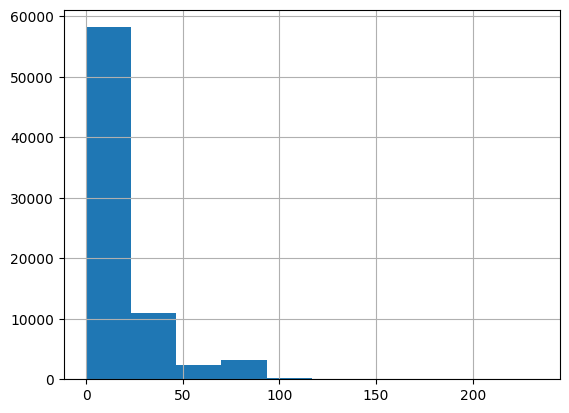

In [31]:
train_data["fare_amount"].hist()

In [ ]:
train_data['trip_distance'].describe()

<Axes: >

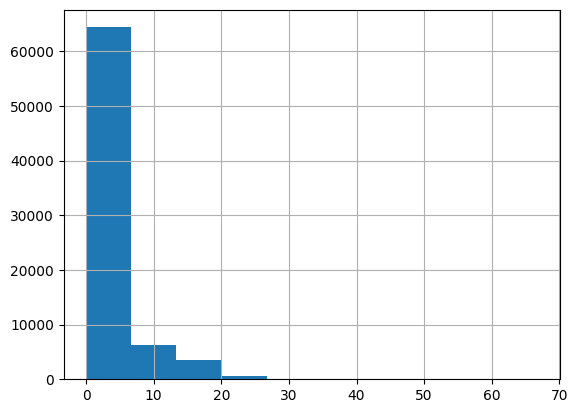

In [46]:
train_data['trip_distance'].hist()

In [86]:
# Feature engineering
train_data['trip_duration_min']=(train_data['tpep_dropoff_datetime']-train_data['tpep_pickup_datetime']).dt.total_seconds()/60
train_data['pickup_hour']=train_data['tpep_pickup_datetime'].dt.hour
train_data['dow']=train_data['tpep_pickup_datetime'].dt.dayofweek
# train_data['month']=train_data['tpep_pickup_datetime'].dt.month
train_data['is_weekend']=train_data.apply(lambda x: '1' if x.dow>=5 else '0', axis=1)
train_data['avg_speed_miles_per_min']=train_data['trip_distance']/train_data['trip_duration_min']

train_data['tpep_pickup_datetime']=train_data['tpep_pickup_datetime'].dt.date
train_data['tpep_dropoff_datetime']=train_data['tpep_dropoff_datetime'].dt.date

cols_to_exclude=['tip_amount', 'tolls_amount', 'total_amount']
to_keep=[]
for i in train_data.columns.to_list():
    if i not in cols_to_exclude:
        to_keep.append(i)
train_data=train_data.loc[:,to_keep]

In [87]:
train_data

,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,passenger_count,RatecodeID,payment_type,fare_amount,trip_duration_min,pickup_hour,dow,is_weekend,avg_speed_miles_per_min
0,2026-01-08,2026-01-09,132,152,35.76,1,2,1,70.0,69.516667,23,3,0,0.514409
1,2026-01-16,2026-01-16,87,211,1.60,1,1,1,12.8,13.716667,20,4,0,0.116646
2,2026-01-24,2026-01-24,142,142,0.50,1,1,2,4.4,2.116667,9,5,1,0.236220
3,2026-01-07,2026-01-07,161,234,1.36,1,1,1,16.3,18.133333,12,2,0,0.075000
4,2026-01-17,2026-01-17,237,141,0.88,1,1,1,8.6,6.983333,23,5,1,0.126014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74995,2026-01-19,2026-01-19,138,237,8.46,1,1,4,33.1,18.066667,1,0,0,0.468266
74996,2026-01-05,2026-01-05,161,236,1.76,1,1,1,16.3,17.683333,12,0,0,0.099529
74997,2026-01-28,2026-01-28,161,68,1.71,1,1,1,15.6,16.950000,22,2,0,0.100885
74998,2026-01-09,2026-01-09,100,234,1.05,1,1,1,10.0,9.516667,21,4,0,0.110333


In [88]:
numerical_cols=['trip_distance', 'passenger_count', 'trip_duration_min', 'pickup_hour','avg_speed_miles_per_min', 'fare_amount']
train_data[numerical_cols].corr()

,trip_distance,passenger_count,trip_duration_min,pickup_hour,avg_speed_miles_per_min,fare_amount
trip_distance,1.000000,0.030464,0.429825,-0.015554,0.173212,0.919807
passenger_count,0.030464,1.000000,-0.001106,0.029115,0.009086,0.050353
trip_duration_min,0.429825,-0.001106,1.000000,-0.022991,0.016929,0.434327
pickup_hour,-0.015554,0.029115,-0.022991,1.000000,-0.019148,-0.010232
avg_speed_miles_per_min,0.173212,0.009086,0.016929,-0.019148,1.000000,0.149774
fare_amount,0.919807,0.050353,0.434327,-0.010232,0.149774,1.000000


In [89]:
cat_columns=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'RatecodeID', 'payment_type', 'dow', 'is_weekend']
for i in train_data[cat_columns].columns.to_list():
    groups = [
        train_data[train_data[i] == c]["fare_amount"]
        for c in train_data[i].unique()
    ]
    
    f_stat, p_val = f_oneway(*groups)
    
    print(i,':',  p_val)

tpep_pickup_datetime : 7.282595504297912e-72
tpep_dropoff_datetime : 3.884966810039375e-71
PULocationID : 0.0
DOLocationID : 0.0
RatecodeID : 0.0
payment_type : 2.4182067426327278e-17
dow : 2.090033785881608e-24
is_weekend : 2.3558087195741215e-13


In [129]:
train_data=train_data.reset_index(drop=True)
x=train_data.drop('fare_amount', axis=1)
y=train_data['fare_amount']
y=y.to_frame().reset_index(drop=True)

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [131]:
num_cols=['trip_distance', 'passenger_count', 'trip_duration_min', 'pickup_hour','avg_speed_miles_per_min']
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_columns)
])

model=LinearRegression()

model_pipe=Pipeline([('preprocess', preprocessor),
                    ('model', model)])

model_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [136]:
y_pred=model_pipe.predict(x_test)
test=pd.DataFrame()
test['y_test']=y_test
test['y_pred']=y_pred
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)

print('MAE = ', mae)
print('MSE = ', mse)
print('RMSE = ', rmse)

MAE =  2.9767114939503605
MSE =  27.59621300715064
RMSE =  5.253209781376587


In [138]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_columns)
])

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    objective="reg:squarederror"
)

model_pipe=Pipeline([('preprocess', preprocessor),
                    ('model', model)])

model_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [139]:
y_pred=model_pipe.predict(x_test)
test=pd.DataFrame()
test['y_test']=y_test
test['y_pred']=y_pred
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)

print('MAE = ', mae)
print('MSE = ', mse)
print('RMSE = ', rmse)

MAE =  0.801738440990448
MSE =  7.754357814788818
RMSE =  2.7846648693084717


In [174]:
param_grid={'model__n_estimators': [500]}
grid = GridSearchCV(
    estimator=model_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'model__n_estimators': [500]}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

In [168]:
grid.best_params_

{'model__n_estimators': 500}

In [171]:
grid.cv_results_['mean_test_score'][0]

np.float64(-2.7218910694122314)

In [172]:
grid.best_score_

np.float64(-2.7218910694122314)

In [148]:
y_pred_cv=grid.predict(x_test)

In [149]:
test=pd.DataFrame()
test['y_test']=y_test
test['y_pred']=y_pred_cv
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)

print('MAE = ', mae)
print('MSE = ', mse)
print('RMSE = ', rmse)

MAE =  0.801738440990448
MSE =  7.754357814788818
RMSE =  2.7846648693084717
